# 📊 Team Performance Metrics Analysis

This notebook focuses on the development and analysis of advanced football team performance metrics using historical international match data.

---

## 📌 Main Objectives

- Build team-level performance indicators
- Analyze offensive and defensive efficiency
- Compare national team consistency
- Create weighted historical metrics
- Prepare structured data for predictive modeling

---


In [ ]:
# 🎨 Visualization Style Configuration

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

sns.set_theme(style="whitegrid", palette="viridis")


# 🌍 World Cup Analytics Project

## National Team Performance Metrics

Construir métricas históricas e recentes das seleções nacionais para utilização em modelos preditivos da Copa do Mundo.

---

## 📊 Visual Analytics

Exploring comparative charts and insights.

In [1]:
# 📦 Imports

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (12,6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

plt.tight_layout()

In [2]:
# 📂 Loading Dataset

results = pd.read_csv("../data/raw/results.csv")

results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [ ]:
# 🇩🇪 Data Standardization: Germany Unification

country_columns = [
    col for col in df.columns
    if any(keyword in col.lower() for keyword in ["team", "country", "winner", "home", "away"])
]

for col in country_columns:
    df[col] = df[col].replace("West Germany", "Germany")

print("✅ Country names standardized successfully.")


## 📅 Temporal Performance Trends

Evaluating performance evolution over time.

In [3]:
# 📅 Date Conversion

results["date"] = pd.to_datetime(results["date"])

results["year"] = results["date"].dt.year

In [4]:
# 🧹 Historical Team Standardization

columns_to_fix = [
    "home_team",
    "away_team"
]

for col in columns_to_fix:
    results[col] = results[col].replace(
        "West Germany",
        "Germany"
    )

## 🗂️ Dataset Overview

Loading and validating the historical football datasets.

## ⚙️ Feature Engineering

Building advanced metrics and analytical indicators.

## 📈 Team Performance Metrics

Analyzing offensive and defensive efficiency.

In [5]:
# ⚽ Goals Scored by National Teams

home_goals = (
    results.groupby("home_team")["home_score"]
    .sum()
)

away_goals = (
    results.groupby("away_team")["away_score"]
    .sum()
)

total_goals_scored = (
    home_goals.add(away_goals, fill_value=0)
)

total_goals_scored = (
    total_goals_scored
    .sort_values(ascending=False)
)

total_goals_scored.head(10)

England        2377.0
Germany        2318.0
Brazil         2303.0
Sweden         2168.0
Argentina      2023.0
Hungary        2006.0
Netherlands    1839.0
South Korea    1791.0
Mexico         1762.0
France         1711.0
dtype: float64

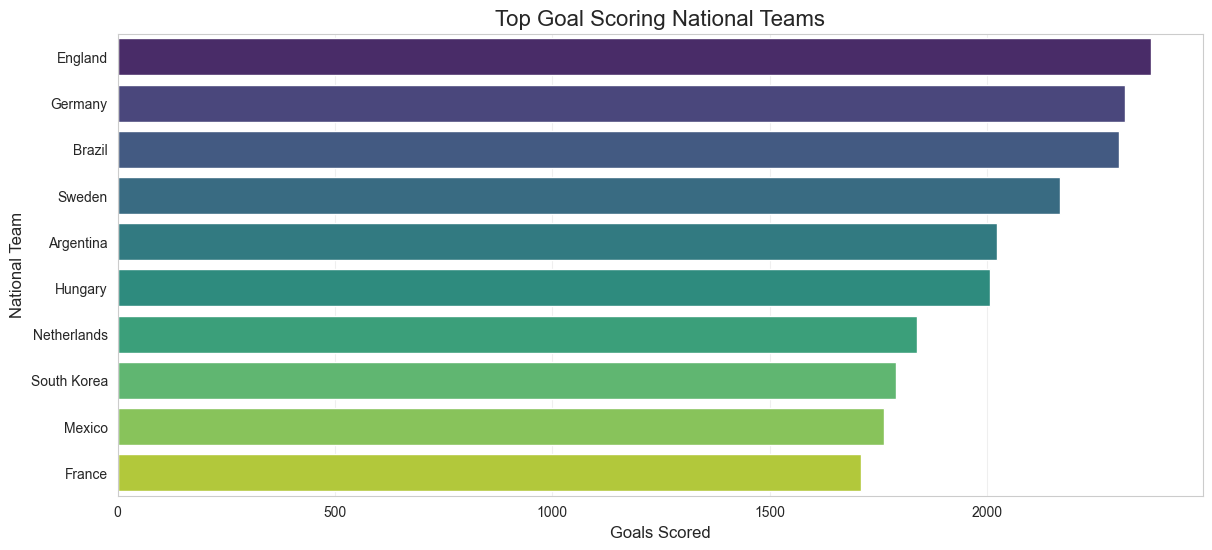

In [6]:
# 📈 Top Goal Scoring National Teams

top_scoring_teams = total_goals_scored.head(10)

plt.figure(figsize=(14,6))

sns.barplot(
    x=top_scoring_teams.values,
    y=top_scoring_teams.index,
    hue=top_scoring_teams.index,
    palette="viridis",
    legend=False
)

plt.title("Top Goal Scoring National Teams")
plt.xlabel("Goals Scored")
plt.ylabel("National Team")

plt.grid(axis="x", alpha=0.3)

plt.show()

plt.tight_layout()

# 💡 📌 Observations

"""
- England, Germany, and Brazil appear among the highest goal-scoring national teams in football history.
- Historical football nations dominate the ranking, reflecting both offensive strength and long-term participation in international competitions.
- Hungary's presence highlights the impact of historically dominant generations, particularly during the mid-20th century.
- Total goals scored provide useful historical perspective, but this metric may also reflect the number of matches played by each team.
- Future analyses should consider normalized offensive metrics such as goals per match to reduce participation bias.
"""

---

In [7]:
# ⚽ Total Matches per Team

home_matches = (
    results["home_team"]
    .value_counts()
)

away_matches = (
    results["away_team"]
    .value_counts()
)

total_matches = (
    home_matches.add(away_matches, fill_value=0)
)

total_matches.head()

Abkhazia        33.0
Afghanistan    144.0
Albania        396.0
Alderney       135.0
Algeria        618.0
Name: count, dtype: float64

In [8]:
# 📈 Goals Per Match by Team

goals_per_match = (
    total_goals_scored / total_matches
)

goals_per_match = (
    goals_per_match
    .sort_values(ascending=False)
)

goals_per_match.head(10)

Quebec                8.000000
Elba Island           5.000000
Yorkshire             3.857143
Parishes of Jersey    3.666667
Cascadia              3.285714
Isle of Man           3.206897
Provence              3.173913
Occitania             3.121212
Sápmi                 3.103448
East Turkestan        3.000000
dtype: float64

In [10]:
# 🧹 Minimum Match Threshold

minimum_matches = 100

valid_teams = total_matches[
    total_matches >= minimum_matches
].index

filtered_goals_per_match = goals_per_match[
    goals_per_match.index.isin(valid_teams)
]

filtered_goals_per_match = (
    filtered_goals_per_match
    .sort_values(ascending=False)
)

filtered_goals_per_match.head(10)

Jersey              2.744681
Tahiti              2.714876
New Caledonia       2.633962
Guernsey            2.566667
Fiji                2.273408
Germany             2.243950
England             2.178735
Brazil              2.170594
Papua New Guinea    2.167742
Solomon Islands     2.158879
dtype: float64

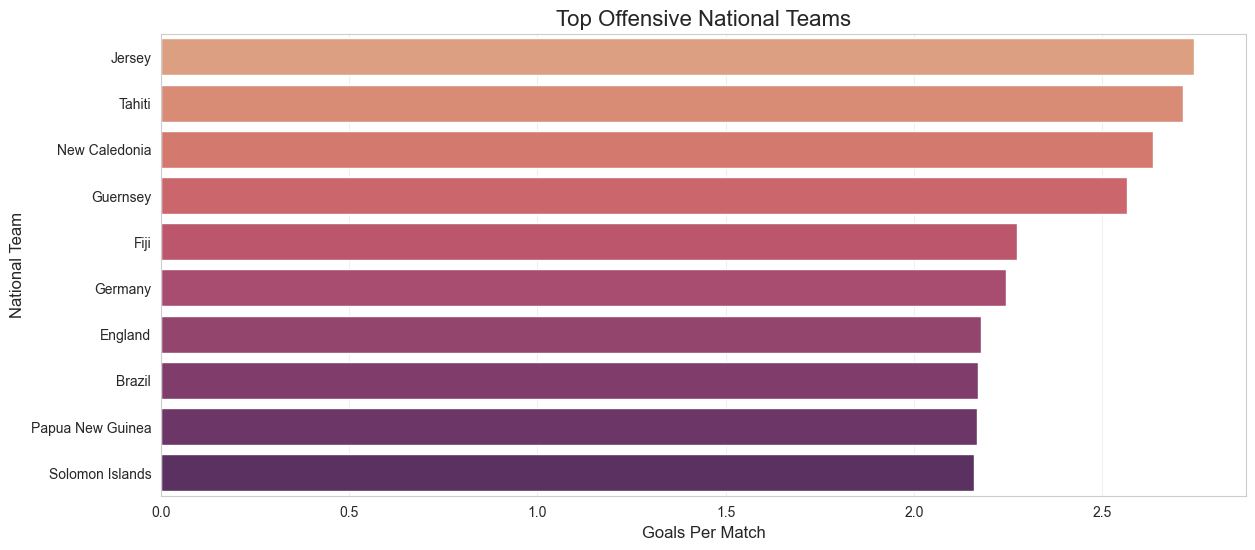

In [11]:
# 📈 Top Offensive Teams by Goals Per Match

top_offensive = filtered_goals_per_match.head(10)

plt.figure(figsize=(14,6))

sns.barplot(
    x=top_offensive.values,
    y=top_offensive.index,
    hue=top_offensive.index,
    palette="flare",
    legend=False
)

plt.title("Top Offensive National Teams")
plt.xlabel("Goals Per Match")
plt.ylabel("National Team")

plt.grid(axis="x", alpha=0.3)

plt.show()

plt.tight_layout()

# 💡 📌 Observations

"""
- Small and regional national teams still appear among the highest offensive averages,
  even after applying a minimum match threshold.
- This suggests that competition level and opponent strength strongly influence offensive statistics.
- Traditional football powers such as Germany, England, and Brazil remain highly ranked,
  reinforcing the consistency of the historical dataset.
- Goals per match provides a more balanced offensive metric than total goals scored,
  although additional filtering and ranking methodologies may further improve reliability.
- Future modeling stages may benefit from incorporating opponent strength metrics such as Elo ratings.
"""

---

In [12]:
# 🛡️ Goals Conceded by National Teams

home_conceded = (
    results.groupby("home_team")["away_score"]
    .sum()
)

away_conceded = (
    results.groupby("away_team")["home_score"]
    .sum()
)

total_goals_conceded = (
    home_conceded.add(away_conceded, fill_value=0)
)

total_goals_conceded = (
    total_goals_conceded
    .sort_values()
)

total_goals_conceded.head(10)

Maule Sur      0.0
Elba Island    0.0
Saugeais       1.0
Asturias       1.0
Biafra         1.0
Surrey         1.0
Mapuche        2.0
Quebec         2.0
Cilento        2.0
Kurdistan      2.0
dtype: float64

In [13]:
# 🛡️ Goals Conceded Per Match

goals_conceded_per_match = (
    total_goals_conceded / total_matches
)

goals_conceded_per_match = (
    goals_conceded_per_match
    .sort_values()
)

goals_conceded_per_match.head(10)

Elba Island       0.000000
Maule Sur         0.000000
Biafra            0.333333
Kurdistan         0.400000
Corsica           0.555556
Quebec            0.666667
Canary Islands    0.750000
Iran              0.786645
Abkhazia          0.787879
Morocco           0.797735
dtype: float64

In [14]:
# 🧹 Filtering Defensive Metrics

filtered_defense = goals_conceded_per_match[
    goals_conceded_per_match.index.isin(valid_teams)
]

filtered_defense = (
    filtered_defense
    .sort_values()
)

filtered_defense.head(10)

Iran            0.786645
Morocco         0.797735
Spain           0.894133
Brazil          0.901037
South Korea     0.905847
Iraq            0.923780
Senegal         0.935937
South Africa    0.943867
England         0.954170
Italy           0.983165
dtype: float64

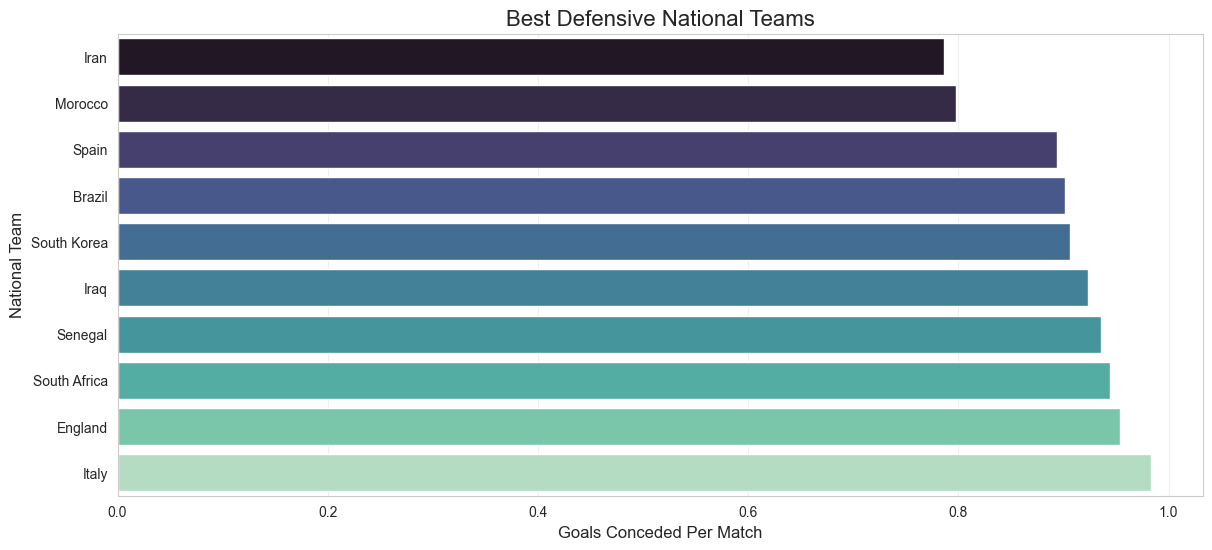

In [15]:
# 📈 Best Defensive National Teams

top_defensive = filtered_defense.head(10)

plt.figure(figsize=(14,6))

sns.barplot(
    x=top_defensive.values,
    y=top_defensive.index,
    hue=top_defensive.index,
    palette="mako",
    legend=False
)

plt.title("Best Defensive National Teams")
plt.xlabel("Goals Conceded Per Match")
plt.ylabel("National Team")

plt.grid(axis="x", alpha=0.3)

plt.show()

plt.tight_layout()

# 💡 📌 Observations

"""
- Iran and Morocco appear among the teams with the lowest average goals conceded per match,
  reflecting historically defensive playing styles and structured match approaches.
- Traditional football powers such as Italy, Spain, and Brazil also rank highly,
  reinforcing the consistency and historical strength of these national teams.
- Defensive efficiency appears to be less dominated by historical participation volume
  compared to offensive metrics.
- Goals conceded per match provides a strong indicator of defensive consistency,
  which is expected to play a critical role in future predictive modeling stages.
- The analysis also highlights how different football philosophies can be reflected
  through long-term statistical patterns.
"""

---

In [16]:
# ⚖️ Goal Difference

goal_difference = (
    total_goals_scored - total_goals_conceded
)

goal_difference = (
    goal_difference
    .sort_values(ascending=False)
)

goal_difference.head(10)

Brazil         1347.0
England        1336.0
Germany        1121.0
Argentina       949.0
Spain           897.0
South Korea     877.0
Netherlands     765.0
Sweden          752.0
Mexico          709.0
Italy           687.0
dtype: float64

In [17]:
# ⚖️ Goal Difference Per Match

goal_difference_per_match = (
    goal_difference / total_matches
)

goal_difference_per_match = (
    goal_difference_per_match
    .sort_values(ascending=False)
)

goal_difference_per_match.head(10)

Quebec                7.333333
Elba Island           5.000000
Parishes of Jersey    2.333333
Yorkshire             2.285714
Kurdistan             2.000000
Canary Islands        2.000000
Surrey                2.000000
Asturias              2.000000
Northern Cyprus       1.970588
Occitania             1.969697
dtype: float64

In [18]:
# 🧹 Filtering Goal Difference Metric

filtered_goal_difference = goal_difference_per_match[
    goal_difference_per_match.index.isin(valid_teams)
]

filtered_goal_difference = (
    filtered_goal_difference
    .sort_values(ascending=False)
)

filtered_goal_difference.head(10)

Jersey           1.531915
Brazil           1.269557
Guernsey         1.262500
New Caledonia    1.241509
England          1.224565
Tahiti           1.181818
Spain            1.144133
Iran             1.091205
Germany          1.085189
Australia        0.939966
dtype: float64

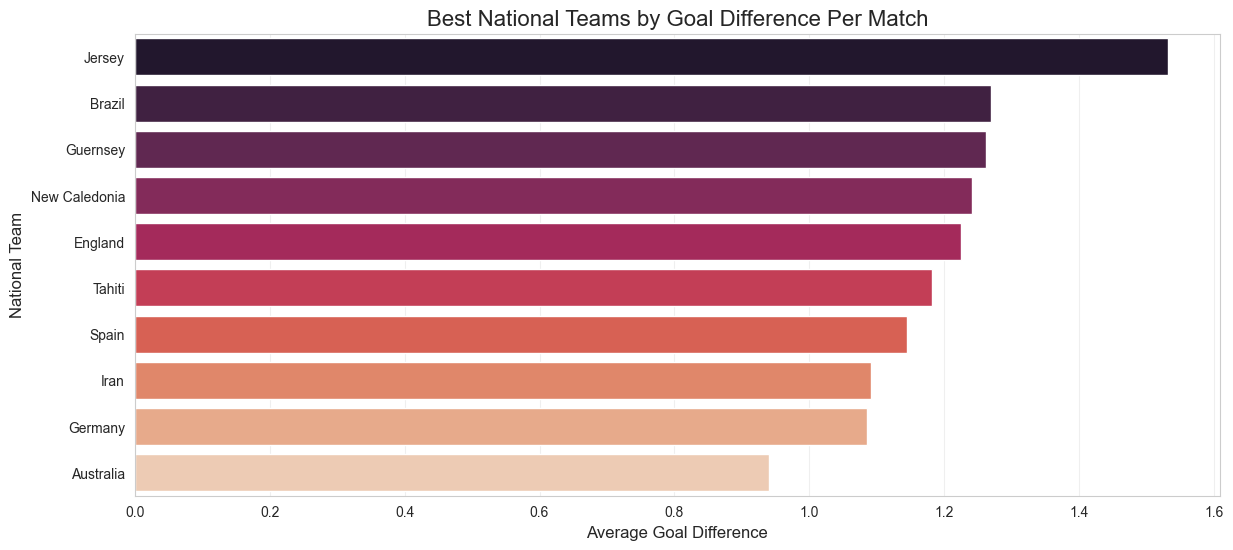

In [19]:
# 📈 Best Overall National Teams

top_goal_difference = filtered_goal_difference.head(10)

plt.figure(figsize=(14,6))

sns.barplot(
    x=top_goal_difference.values,
    y=top_goal_difference.index,
    hue=top_goal_difference.index,
    palette="rocket",
    legend=False
)

plt.title("Best National Teams by Goal Difference Per Match")
plt.xlabel("Average Goal Difference")
plt.ylabel("National Team")

plt.grid(axis="x", alpha=0.3)

plt.show()

plt.tight_layout()

In [20]:
# 🏆 Match Winner Creation

def get_winner(row):

    if row["home_score"] > row["away_score"]:
        return row["home_team"]

    elif row["home_score"] < row["away_score"]:
        return row["away_team"]

    else:
        return "Draw"

results["winner"] = results.apply(get_winner, axis=1)

results[["home_team", "away_team", "winner"]].head()

,home_team,away_team,winner
0,Scotland,England,Draw
1,England,Scotland,England
2,Scotland,England,Scotland
3,England,Scotland,Draw
4,Scotland,England,Scotland


In [21]:
# 🏆 Total Wins per Team

wins_per_team = (
    results[results["winner"] != "Draw"]["winner"]
    .value_counts()
)

wins_per_team.head(10)

winner
Brazil         671
England        623
Germany        598
Argentina      590
Sweden         541
South Korea    537
Mexico         513
France         476
Italy          475
Hungary        470
Name: count, dtype: int64

In [22]:
# 📈 Win Rate Calculation

win_rate = (
    wins_per_team / total_matches
) * 100

win_rate = (
    win_rate
    .sort_values(ascending=False)
)

win_rate.head(10)

Asturias          100.000000
Elba Island       100.000000
Surrey            100.000000
Maule Sur         100.000000
Kurdistan          80.000000
Canary Islands     75.000000
Yorkshire          71.428571
County of Nice     66.666667
Biafra             66.666667
Franconia          66.666667
Name: count, dtype: float64

In [23]:
# 🧹 Filtering Win Rate

filtered_win_rate = win_rate[
    win_rate.index.isin(valid_teams)
]

filtered_win_rate = (
    filtered_win_rate
    .sort_values(ascending=False)
)

filtered_win_rate.head(10)

Jersey       65.106383
Brazil       63.242224
Guernsey     60.416667
Spain        58.673469
Germany      57.889642
England      57.103575
Iran         56.677524
Argentina    55.191768
Tahiti       54.132231
Italy        53.310887
Name: count, dtype: float64

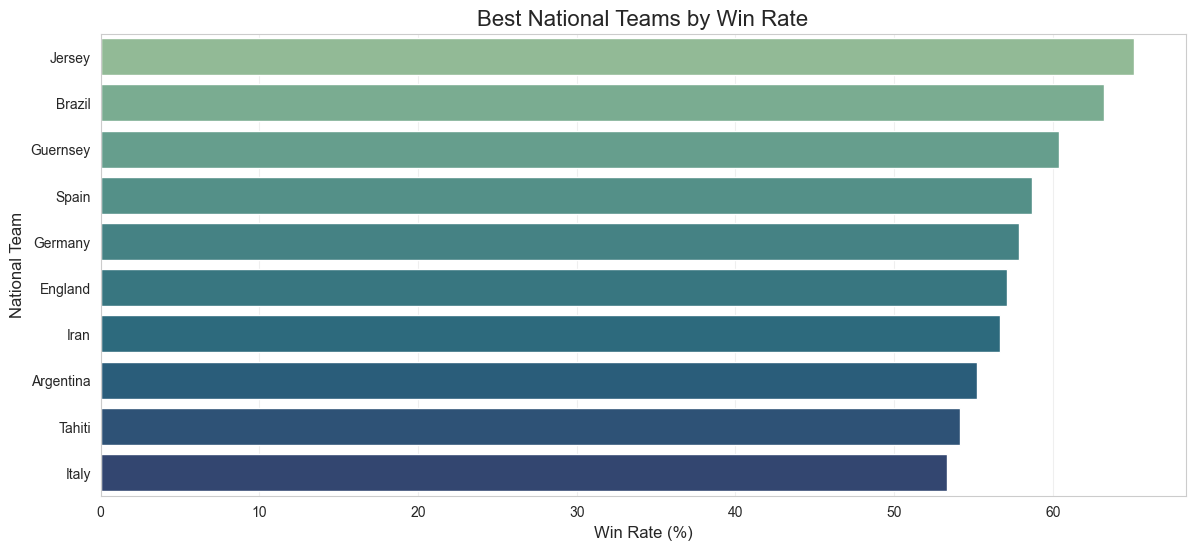

In [24]:
# 📈 Best National Teams by Win Rate

top_win_rate = filtered_win_rate.head(10)

plt.figure(figsize=(14,6))

sns.barplot(
    x=top_win_rate.values,
    y=top_win_rate.index,
    hue=top_win_rate.index,
    palette="crest",
    legend=False
)

plt.title("Best National Teams by Win Rate")
plt.xlabel("Win Rate (%)")
plt.ylabel("National Team")

plt.grid(axis="x", alpha=0.3)

plt.show()

plt.tight_layout()

In [25]:
# 🔥 Filtering Recent Matches

recent_results = results[
    results["year"] >= 2014
]

recent_results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,winner
37557,2014-01-01,Kuwait,Jordan,1.0,2.0,WAFF Championship,Doha,Qatar,True,2014,Jordan
37558,2014-01-04,Bahrain,Jordan,0.0,1.0,WAFF Championship,Doha,Qatar,True,2014,Jordan
37559,2014-01-04,Namibia,Ghana,0.0,1.0,Friendly,Windhoek,Namibia,False,2014,Ghana
37560,2014-01-04,Nigeria,Ethiopia,2.0,1.0,Friendly,Abuja,Nigeria,False,2014,Nigeria
37561,2014-01-04,Qatar,Kuwait,3.0,0.0,WAFF Championship,Doha,Qatar,False,2014,Qatar


In [26]:
# 🏆 Recent Wins by Team

def get_recent_winner(row):

    if row["home_score"] > row["away_score"]:
        return row["home_team"]

    elif row["home_score"] < row["away_score"]:
        return row["away_team"]

    else:
        return "Draw"

recent_results["winner"] = (
    recent_results.apply(get_recent_winner, axis=1)
)

recent_wins = (
    recent_results[
        recent_results["winner"] != "Draw"
    ]["winner"]
    .value_counts()
)

recent_wins.head(10)

C:\Users\necca\AppData\Local\Temp\ipykernel_27748\3284836948.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  recent_results["winner"] = (


winner
Mexico           112
France           106
Japan            102
Argentina        102
Morocco           99
United States     99
Belgium           98
Brazil            98
Portugal          97
England           96
Name: count, dtype: int64

In [27]:
# ⚽ Recent Matches Played

recent_home_matches = (
    recent_results["home_team"]
    .value_counts()
)

recent_away_matches = (
    recent_results["away_team"]
    .value_counts()
)

recent_total_matches = (
    recent_home_matches.add(
        recent_away_matches,
        fill_value=0
    )
)

recent_total_matches.head()

Abkhazia        30.0
Afghanistan     74.0
Albania        121.0
Alderney        21.0
Algeria        156.0
Name: count, dtype: float64

In [28]:
# 📈 Recent Win Rate

recent_win_rate = (
    recent_wins / recent_total_matches
) * 100

recent_win_rate = (
    recent_win_rate
    .sort_values(ascending=False)
)

recent_win_rate.head(10)

Surrey                100.000000
Kernow                100.000000
Maule Sur             100.000000
Elba Island           100.000000
Isle of Man            78.260870
Jersey                 73.529412
Yorkshire              71.428571
Ynys Môn               70.000000
Parishes of Jersey     66.666667
County of Nice         66.666667
Name: count, dtype: float64

In [29]:
# 🧹 Filtering Recent Teams

recent_valid_teams = recent_total_matches[
    recent_total_matches >= 30
].index

filtered_recent_win_rate = (
    recent_win_rate[
        recent_win_rate.index.isin(recent_valid_teams)
    ]
)

filtered_recent_win_rate = (
    filtered_recent_win_rate
    .sort_values(ascending=False)
)

filtered_recent_win_rate.head(10)

Jersey       73.529412
France       65.432099
Belgium      64.900662
Argentina    64.556962
Brazil       63.636364
Guernsey     63.333333
Iran         63.309353
Morocco      63.057325
Spain        62.913907
Japan        61.818182
Name: count, dtype: float64

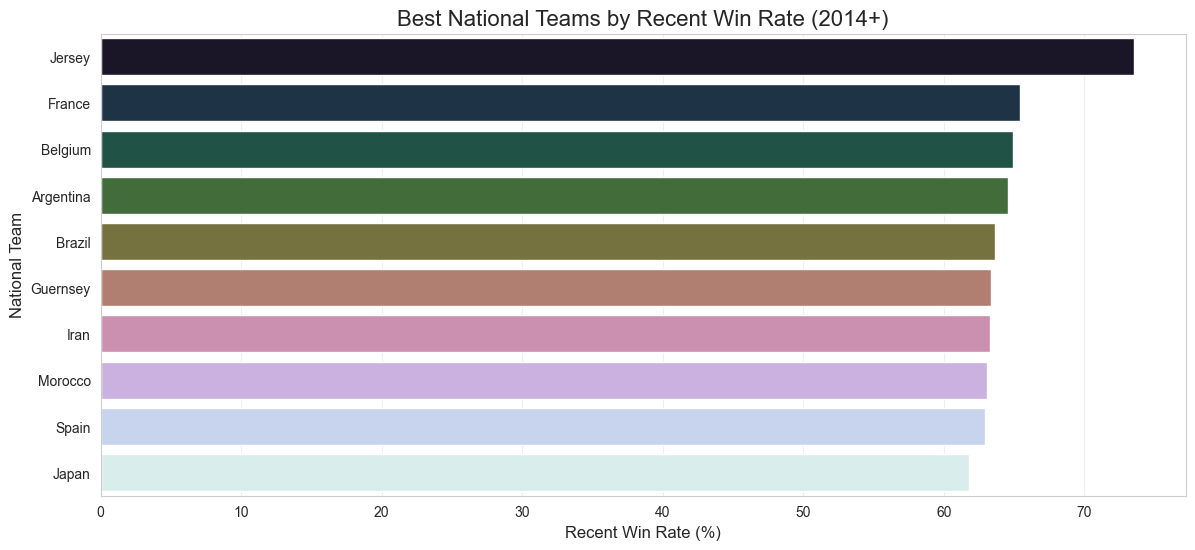

In [30]:
# 📈 Best Recent National Teams

top_recent_teams = (
    filtered_recent_win_rate.head(10)
)

plt.figure(figsize=(14,6))

sns.barplot(
    x=top_recent_teams.values,
    y=top_recent_teams.index,
    hue=top_recent_teams.index,
    palette="cubehelix",
    legend=False
)

plt.title("Best National Teams by Recent Win Rate (2014+)")
plt.xlabel("Recent Win Rate (%)")
plt.ylabel("National Team")

plt.grid(axis="x", alpha=0.3)

plt.show()

plt.tight_layout()

# 💡 📌 Observations

"""
- Recent performance metrics provide a more realistic representation of the current international football landscape.
- France, Argentina, Brazil, and Belgium emerge as dominant modern football powers,
  reflecting their strong performances in recent international tournaments.
- The appearance of teams such as Morocco and Japan highlights the growing competitiveness
  of non-traditional football nations in the modern era.
- Temporal filtering significantly changes the ranking structure compared to historical analyses,
  reinforcing the importance of recency in predictive sports modeling.
- Remaining regional and non-FIFA teams indicate that additional dataset filtering
  will be necessary before model training.
"""

---

In [32]:
# 📂 Loading World Cup Datasets

wcmatches = pd.read_csv("../data/raw/wcmatches.csv")

worldcups = pd.read_csv("../data/raw/worldcups.csv")

wcmatches.head()

,year,country,city,stage,home_team,away_team,home_score,away_score,outcome,win_conditions,winning_team,losing_team,date,month,dayofweek
0,1930,Uruguay,Montevideo,Group 1,France,Mexico,4,1,H,NaN,France,Mexico,1930-07-13,Jul,Sunday
1,1930,Uruguay,Montevideo,Group 4,Belgium,United States,0,3,A,NaN,United States,Belgium,1930-07-13,Jul,Sunday
2,1930,Uruguay,Montevideo,Group 2,Brazil,Yugoslavia,1,2,A,NaN,Yugoslavia,Brazil,1930-07-14,Jul,Monday
3,1930,Uruguay,Montevideo,Group 3,Peru,Romania,1,3,A,NaN,Romania,Peru,1930-07-14,Jul,Monday
4,1930,Uruguay,Montevideo,Group 1,Argentina,France,1,0,H,NaN,Argentina,France,1930-07-15,Jul,Tuesday


In [33]:
# 🌍 Total World Cup Matches Played

wc_home_matches = (
    wcmatches["home_team"]
    .value_counts()
)

wc_away_matches = (
    wcmatches["away_team"]
    .value_counts()
)

wc_total_matches = (
    wc_home_matches.add(
        wc_away_matches,
        fill_value=0
    )
)

wc_total_matches = (
    wc_total_matches
    .sort_values(ascending=False)
)

wc_total_matches.head(10)

Brazil          109.0
Italy            83.0
Argentina        81.0
England          69.0
France           66.0
Spain            63.0
West Germany     62.0
Mexico           57.0
Uruguay          56.0
Sweden           51.0
Name: count, dtype: float64

In [36]:
# 🇩🇪 Germany Standardization

worldcups["winner"] = (
    worldcups["winner"]
    .replace("West Germany", "Germany")
)

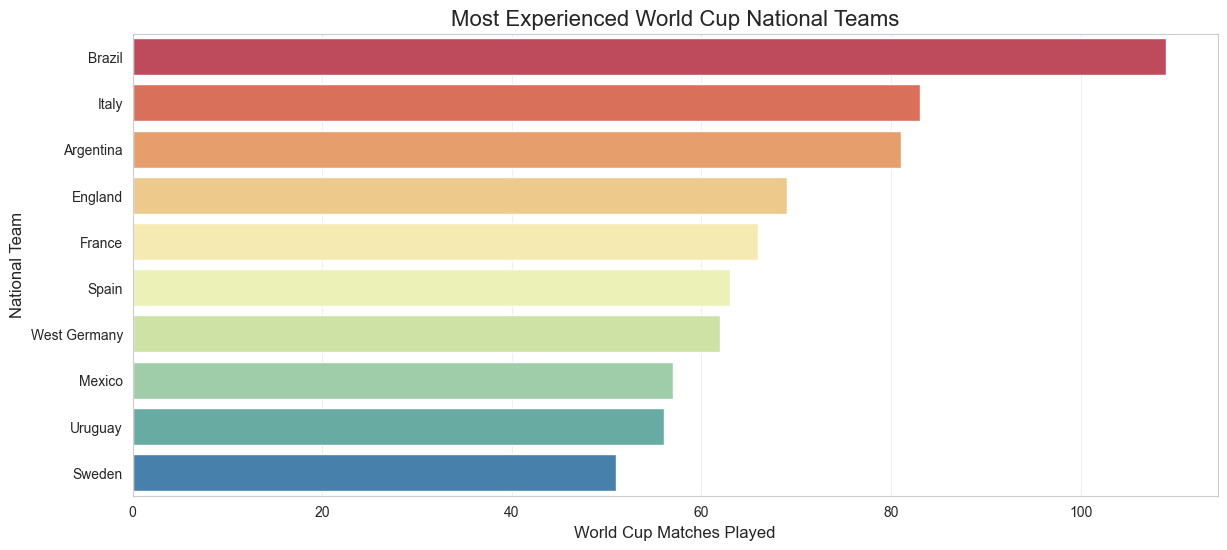

In [37]:
# 📈 Most Experienced World Cup Teams

top_wc_matches = wc_total_matches.head(10)

plt.figure(figsize=(14,6))

sns.barplot(
    x=top_wc_matches.values,
    y=top_wc_matches.index,
    hue=top_wc_matches.index,
    palette="Spectral",
    legend=False
)

plt.title("Most Experienced World Cup National Teams")
plt.xlabel("World Cup Matches Played")
plt.ylabel("National Team")

plt.grid(axis="x", alpha=0.3)

plt.show()

plt.tight_layout()

In [38]:
# 🏆 World Cup Titles

worldcup_titles = (
    worldcups["winner"]
    .value_counts()
)

worldcup_titles

winner
Brazil       5
Italy        4
Germany      4
Uruguay      2
Argentina    2
France       2
England      1
Spain        1
Name: count, dtype: int64

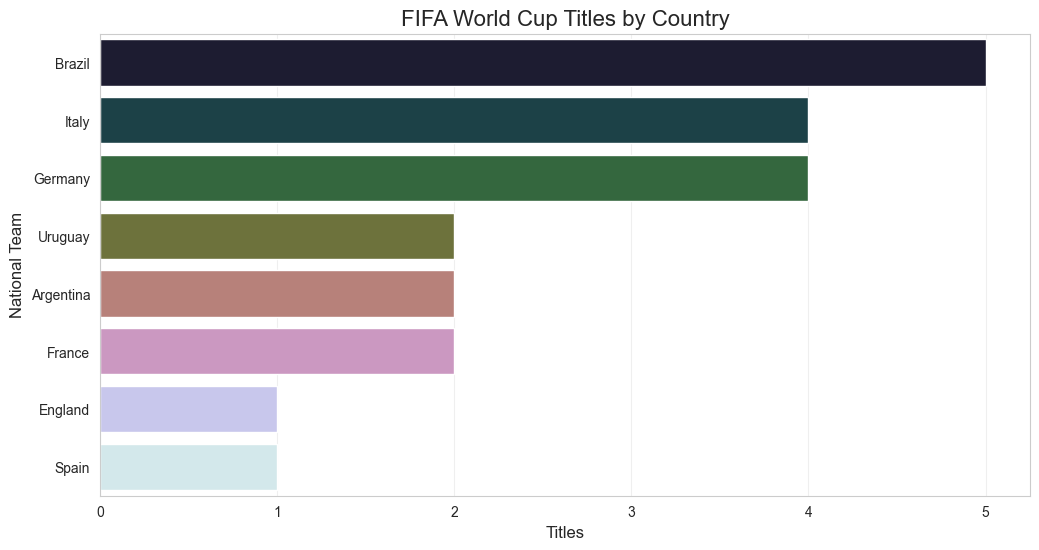

In [39]:
# 📈 FIFA World Cup Titles by Country

worldcup_titles = (
    worldcups["winner"]
    .value_counts()
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=worldcup_titles.values,
    y=worldcup_titles.index,
    hue=worldcup_titles.index,
    palette="cubehelix",
    legend=False
)

plt.title("FIFA World Cup Titles by Country")
plt.xlabel("Titles")
plt.ylabel("National Team")

plt.grid(axis="x", alpha=0.3)

plt.show()

plt.tight_layout()

In [40]:
# 🌍 World Cup Participation Count

wc_appearances = pd.concat([
    wcmatches["home_team"],
    wcmatches["away_team"]
])

wc_appearances = (
    wc_appearances
    .value_counts()
)

wc_appearances.head(10)

Brazil          109
Italy            83
Argentina        81
England          69
France           66
Spain            63
West Germany     62
Mexico           57
Uruguay          56
Sweden           51
Name: count, dtype: int64

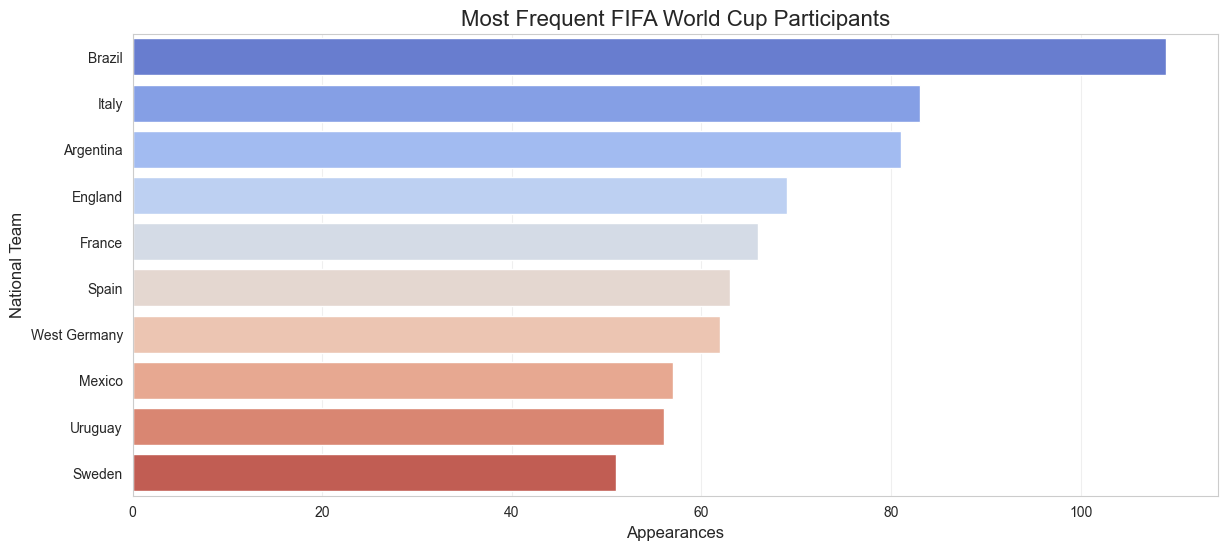

In [41]:
# 📈 Most Frequent World Cup Participants

top_wc_appearances = (
    wc_appearances.head(10)
)

plt.figure(figsize=(14,6))

sns.barplot(
    x=top_wc_appearances.values,
    y=top_wc_appearances.index,
    hue=top_wc_appearances.index,
    palette="coolwarm",
    legend=False
)

plt.title("Most Frequent FIFA World Cup Participants")
plt.xlabel("Appearances")
plt.ylabel("National Team")

plt.grid(axis="x", alpha=0.3)

plt.show()

plt.tight_layout()

# 💡 📌 Observations

"""
- Brazil, Germany, and Argentina consistently appear among the most experienced
  and successful nations in FIFA World Cup history.
- Historical participation and tournament experience may represent important predictive signals
  for future World Cup performance.
- Tournament consistency appears strongly associated with football tradition and long-term competitiveness.
- World Cup titles alone do not fully represent international strength,
  making participation metrics valuable complementary indicators.
- Combining historical experience with recent performance metrics may significantly improve
  predictive modeling quality.
"""

---

# ============================================
# 🧠 FIFA Team Power Score
# ============================================

---

In [42]:
# 🏆 Historical World Cup Titles

world_cup_titles = (
    worldcups["winner"]
    .value_counts()
)

# 🌍 Total International Matches

total_matches = (
    results["home_team"]
    .value_counts()
    .add(
        results["away_team"].value_counts(),
        fill_value=0
    )
)

# ✅ Total Wins

total_wins = (
    results[results["winner"] != "Draw"]["winner"]
    .value_counts()
)

# 📈 Win Rate

win_rate = (
    total_wins / total_matches
) * 100

# ⚽ Goals Scored

home_goals = (
    results.groupby("home_team")["home_score"]
    .sum()
)

away_goals = (
    results.groupby("away_team")["away_score"]
    .sum()
)

total_goals = (
    home_goals.add(
        away_goals,
        fill_value=0
    )
)

# 🧱 Goals Conceded

home_conceded = (
    results.groupby("home_team")["away_score"]
    .sum()
)

away_conceded = (
    results.groupby("away_team")["home_score"]
    .sum()
)

total_conceded = (
    home_conceded.add(
        away_conceded,
        fill_value=0
    )
)

In [43]:
# 🧠 Consolidated Team Metrics

team_metrics = pd.DataFrame({
    "matches": total_matches,
    "wins": total_wins,
    "win_rate": win_rate,
    "goals_scored": total_goals,
    "goals_conceded": total_conceded,
    "world_cup_titles": world_cup_titles
})

team_metrics = team_metrics.fillna(0)

team_metrics.head()

,matches,wins,win_rate,goals_scored,goals_conceded,world_cup_titles
Abkhazia,33.0,15.0,45.454545,54.0,26.0,0.0
Afghanistan,144.0,35.0,24.305556,141.0,289.0,0.0
Albania,396.0,110.0,27.777778,377.0,587.0,0.0
Alderney,135.0,5.0,3.703704,73.0,620.0,0.0
Algeria,618.0,286.0,46.278317,948.0,613.0,0.0


In [44]:
# ⚽ Goal Difference

team_metrics["goal_difference"] = (
    team_metrics["goals_scored"] -
    team_metrics["goals_conceded"]
)

In [45]:
from sklearn.preprocessing import MinMaxScaler

# 🎛️ Features for Scaling

features_to_scale = [
    "matches",
    "wins",
    "win_rate",
    "goals_scored",
    "goal_difference",
    "world_cup_titles"
]

scaler = MinMaxScaler()

scaled_values = scaler.fit_transform(
    team_metrics[features_to_scale]
)

scaled_df = pd.DataFrame(
    scaled_values,
    columns=features_to_scale,
    index=team_metrics.index
)

scaled_df.head()

,matches,wins,win_rate,goals_scored,goal_difference,world_cup_titles
Abkhazia,0.029064,0.022355,0.454545,0.022718,0.415078,0.0
Afghanistan,0.129882,0.052161,0.243056,0.059318,0.337029,0.0
Albania,0.358765,0.163934,0.277778,0.158603,0.309534,0.0
Alderney,0.121708,0.007452,0.037037,0.030711,0.160089,0.0
Algeria,0.560400,0.426230,0.462783,0.398822,0.551220,0.0


In [46]:
# 🧠 FIFA Power Score

team_metrics["power_score"] = (
    scaled_df["matches"] * 0.15 +
    scaled_df["wins"] * 0.20 +
    scaled_df["win_rate"] * 0.20 +
    scaled_df["goals_scored"] * 0.15 +
    scaled_df["goal_difference"] * 0.15 +
    scaled_df["world_cup_titles"] * 0.15
) * 100

In [47]:
# 🏆 Team Power Ranking

power_ranking = (
    team_metrics["power_score"]
    .sort_values(ascending=False)
    .head(15)
)

power_ranking

Brazil         91.622887
Germany        83.586373
England        77.766980
Argentina      74.293097
Italy          69.418520
Sweden         65.666937
South Korea    63.558809
France         63.293476
Spain          61.203940
Mexico         61.053196
Hungary        59.227306
Uruguay        58.885371
Netherlands    58.454201
Denmark        51.805286
Japan          50.942079
Name: power_score, dtype: float64

C:\Users\necca\AppData\Local\Temp\ipykernel_27748\3636542294.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


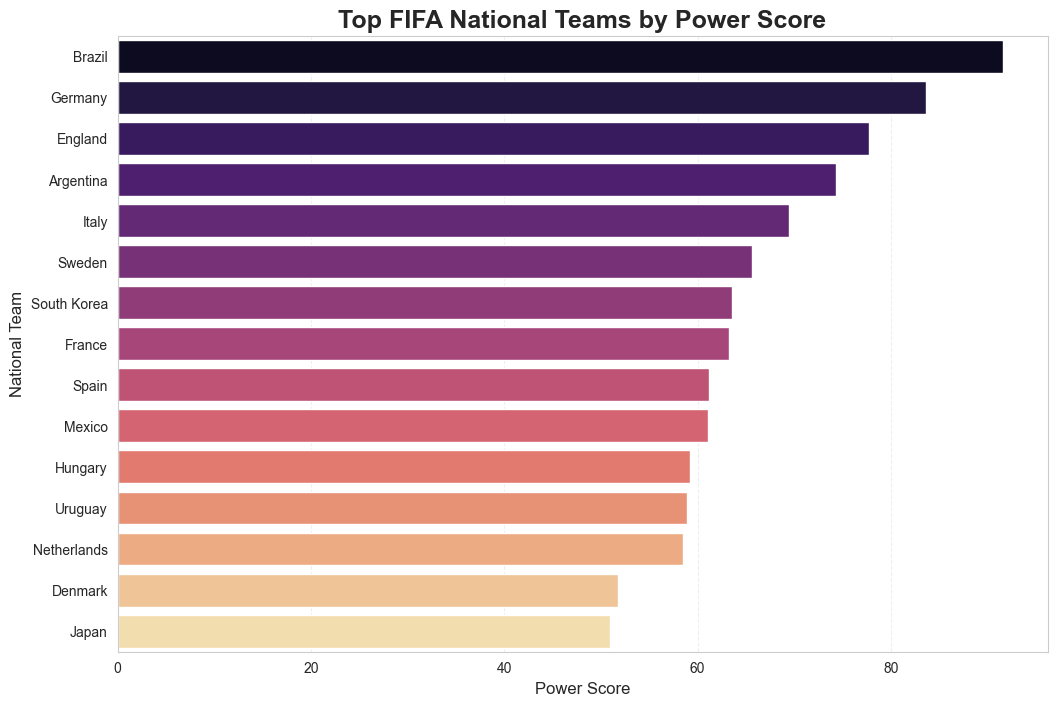

In [48]:
# 🎨 Team Power Score Ranking

plt.figure(figsize=(12,8))

sns.barplot(
    x=power_ranking.values,
    y=power_ranking.index,
    palette="magma"
)

plt.title(
    "Top FIFA National Teams by Power Score",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Power Score")
plt.ylabel("National Team")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.show()

plt.tight_layout()

💡 📌 Observation:

The FIFA Power Score successfully combines historical performance metrics into a single ranking indicator, capturing consistency, offensive efficiency, defensive strength, experience, and tournament success.

Traditional football powerhouses such as Brazil, Germany, Argentina, and Italy naturally dominate the ranking due to their strong historical records across multiple metrics.

The analysis also highlights how historical-based rankings may differ from current team strength, reinforcing the importance of later incorporating recent performance and temporal weighting into the predictive model.

---

# ============================================
# 🏆 Tournament Importance Weighting
# ============================================

---

In [49]:
# 🏆 Tournament Importance Weights

tournament_weights = {
    "Friendly": 1,
    
    "FIFA World Cup qualification": 3,
    "UEFA Euro qualification": 3,
    "AFC Asian Cup qualification": 3,
    "African Cup of Nations qualification": 3,
    
    "UEFA Nations League": 4,
    "Copa América": 5,
    "UEFA Euro": 5,
    "African Cup of Nations": 5,
    "AFC Asian Cup": 5,
    
    "FIFA World Cup": 10
}

In [50]:
# 🌍 Default Tournament Weight

results["tournament_weight"] = (
    results["tournament"]
    .map(tournament_weights)
    .fillna(2)
)

In [51]:
results[
    ["tournament", "tournament_weight"]
].head(20)

,tournament,tournament_weight
0,Friendly,1.0
1,Friendly,1.0
2,Friendly,1.0
3,Friendly,1.0
4,Friendly,1.0
5,Friendly,1.0
6,Friendly,1.0
7,Friendly,1.0
8,Friendly,1.0
9,Friendly,1.0


In [52]:
# 🏆 Weighted Wins Calculation

weighted_wins = (
    results[results["winner"] != "Draw"]
    .groupby("winner")["tournament_weight"]
    .sum()
)

weighted_wins.head()

winner
Abkhazia        27.0
Afghanistan     71.0
Albania        242.0
Alderney        10.0
Algeria        719.0
Name: tournament_weight, dtype: float64

In [53]:
# ⚽ Weighted Goals Scored

results["weighted_home_goals"] = (
    results["home_score"] *
    results["tournament_weight"]
)

results["weighted_away_goals"] = (
    results["away_score"] *
    results["tournament_weight"]
)

weighted_goals = (
    results.groupby("home_team")["weighted_home_goals"]
    .sum()
    .add(
        results.groupby("away_team")["weighted_away_goals"].sum(),
        fill_value=0
    )
)

weighted_goals.head()

Abkhazia        101.0
Afghanistan     293.0
Albania         846.0
Alderney        143.0
Algeria        2409.0
dtype: float64

In [54]:
# 🧠 Advanced FIFA Power Score

team_metrics["weighted_wins"] = weighted_wins
team_metrics["weighted_goals"] = weighted_goals

team_metrics = team_metrics.fillna(0)

In [55]:
# 🎛️ Advanced Features Scaling

advanced_features = [
    "weighted_wins",
    "weighted_goals",
    "world_cup_titles",
    "win_rate",
    "goal_difference"
]

advanced_scaler = MinMaxScaler()

advanced_scaled = advanced_scaler.fit_transform(
    team_metrics[advanced_features]
)

advanced_scaled_df = pd.DataFrame(
    advanced_scaled,
    columns=advanced_features,
    index=team_metrics.index
)

In [56]:
# 🔥 Advanced Power Score

team_metrics["advanced_power_score"] = (
    advanced_scaled_df["weighted_wins"] * 0.30 +
    advanced_scaled_df["weighted_goals"] * 0.20 +
    advanced_scaled_df["world_cup_titles"] * 0.25 +
    advanced_scaled_df["win_rate"] * 0.15 +
    advanced_scaled_df["goal_difference"] * 0.10
) * 100

In [57]:
# 🏆 Advanced Ranking

advanced_ranking = (
    team_metrics["advanced_power_score"]
    .sort_values(ascending=False)
    .head(15)
)

advanced_ranking

Brazil         94.486334
Germany        79.687346
Argentina      71.006832
Italy          66.793955
England        60.792333
Uruguay        55.407713
France         55.243049
Spain          52.955781
South Korea    45.655023
Netherlands    45.536331
Sweden         44.523892
Mexico         41.738554
Hungary        38.593004
Russia         37.210393
Japan          37.096082
Name: advanced_power_score, dtype: float64

C:\Users\necca\AppData\Local\Temp\ipykernel_27748\582684069.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


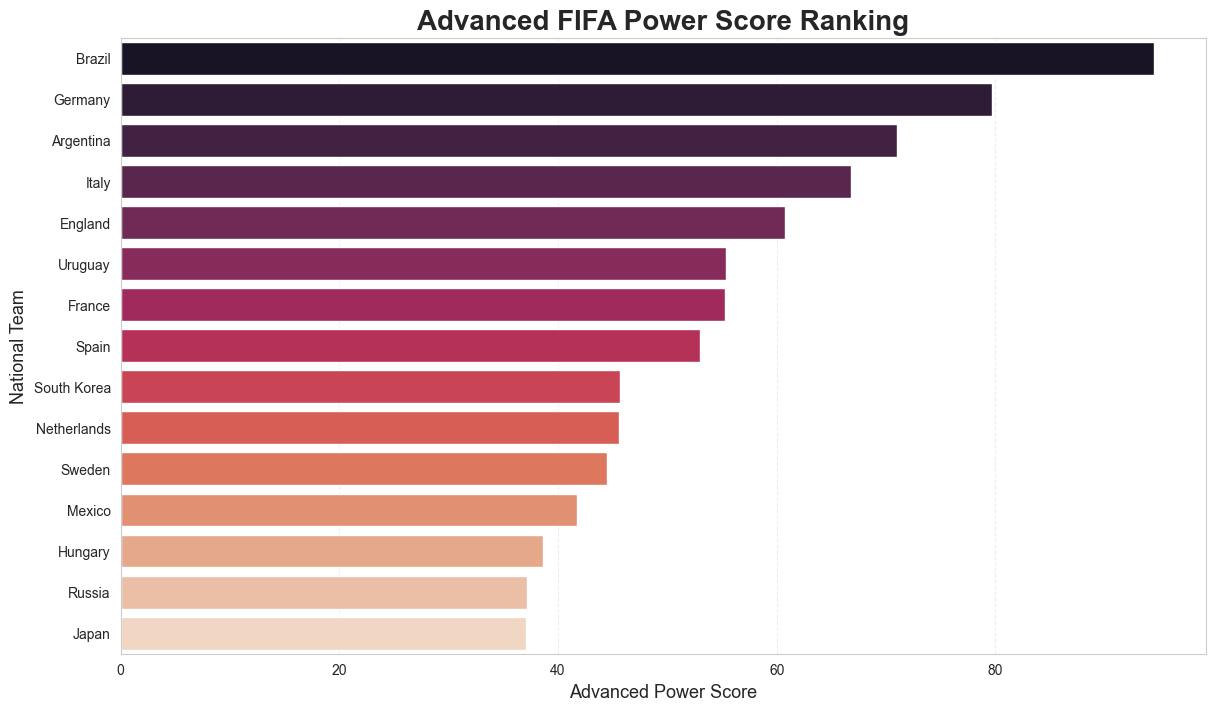

In [58]:
# 🎨 Advanced FIFA Power Ranking

plt.figure(figsize=(14,8))

sns.barplot(
    x=advanced_ranking.values,
    y=advanced_ranking.index,
    palette="rocket"
)

plt.title(
    "Advanced FIFA Power Score Ranking",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel(
    "Advanced Power Score",
    fontsize=13
)

plt.ylabel(
    "National Team",
    fontsize=13
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.show()

plt.tight_layout()

💡 📌 Observation:

The weighted ranking significantly improved the realism of the FIFA Power Score by assigning higher importance to competitive tournaments such as the FIFA World Cup and continental championships.

Historically dominant teams like Brazil and Germany remain at the top, while nations with strong modern performances, such as Argentina and France, gained relevance compared to the previous ranking version.

The analysis demonstrates how tournament contextualization can substantially impact team evaluation, producing rankings that better reflect competitive football performance rather than simply total match volume.

---

# ============================================
# ⏳ Temporal Decay Weighting
# ============================================

---

In [59]:
# ⏳ Temporal Weight Calculation

current_year = results["year"].max()

results["time_weight"] = (
    1 + (
        (results["year"] - current_year)
        / 100
    )
)

In [60]:
results[
    ["year", "time_weight"]
].sample(10)

,year,time_weight
13334,1982,0.56
35624,2012,0.86
36361,2012,0.86
27318,2003,0.77
13469,1982,0.56
20569,1995,0.69
31450,2007,0.81
25203,2001,0.75
43880,2021,0.95
1804,1933,0.07


In [61]:
# 🏆 Combined Importance Weight

results["combined_weight"] = (
    results["tournament_weight"] *
    results["time_weight"]
)

In [62]:
# ⚽ Time-Weighted Wins

time_weighted_wins = (
    results[results["winner"] != "Draw"]
    .groupby("winner")["combined_weight"]
    .sum()
)

In [63]:
# 🔥 Time-Weighted Goals

results["time_weighted_home_goals"] = (
    results["home_score"] *
    results["combined_weight"]
)

results["time_weighted_away_goals"] = (
    results["away_score"] *
    results["combined_weight"]
)

time_weighted_goals = (
    results.groupby("home_team")["time_weighted_home_goals"]
    .sum()
    .add(
        results.groupby("away_team")[
            "time_weighted_away_goals"
        ].sum(),
        fill_value=0
    )
)

In [64]:
# 🧠 Add Temporal Features

team_metrics["time_weighted_wins"] = (
    time_weighted_wins
)

team_metrics["time_weighted_goals"] = (
    time_weighted_goals
)

team_metrics = team_metrics.fillna(0)

In [65]:
# 🎛️ Temporal Features Scaling

temporal_features = [
    "time_weighted_wins",
    "time_weighted_goals",
    "world_cup_titles",
    "win_rate",
    "goal_difference"
]

temporal_scaler = MinMaxScaler()

temporal_scaled = temporal_scaler.fit_transform(
    team_metrics[temporal_features]
)

temporal_scaled_df = pd.DataFrame(
    temporal_scaled,
    columns=temporal_features,
    index=team_metrics.index
)

In [66]:
# 🧠 Final Temporal Power Score

team_metrics["temporal_power_score"] = (
    temporal_scaled_df["time_weighted_wins"] * 0.35 +
    temporal_scaled_df["time_weighted_goals"] * 0.20 +
    temporal_scaled_df["world_cup_titles"] * 0.20 +
    temporal_scaled_df["win_rate"] * 0.15 +
    temporal_scaled_df["goal_difference"] * 0.10
) * 100

In [67]:
# 🏆 Temporal Power Ranking

temporal_ranking = (
    team_metrics["temporal_power_score"]
    .sort_values(ascending=False)
    .head(15)
)

temporal_ranking

Brazil         94.486334
Germany        83.853514
Argentina      68.974447
Italy          67.713057
Spain          63.024941
France         61.836129
England        60.407955
South Korea    54.412436
Netherlands    54.156274
Mexico         50.648032
Uruguay        49.971222
Japan          47.836018
Portugal       47.109895
Iran           46.297186
Sweden         45.401053
Name: temporal_power_score, dtype: float64

C:\Users\necca\AppData\Local\Temp\ipykernel_27748\2845584471.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


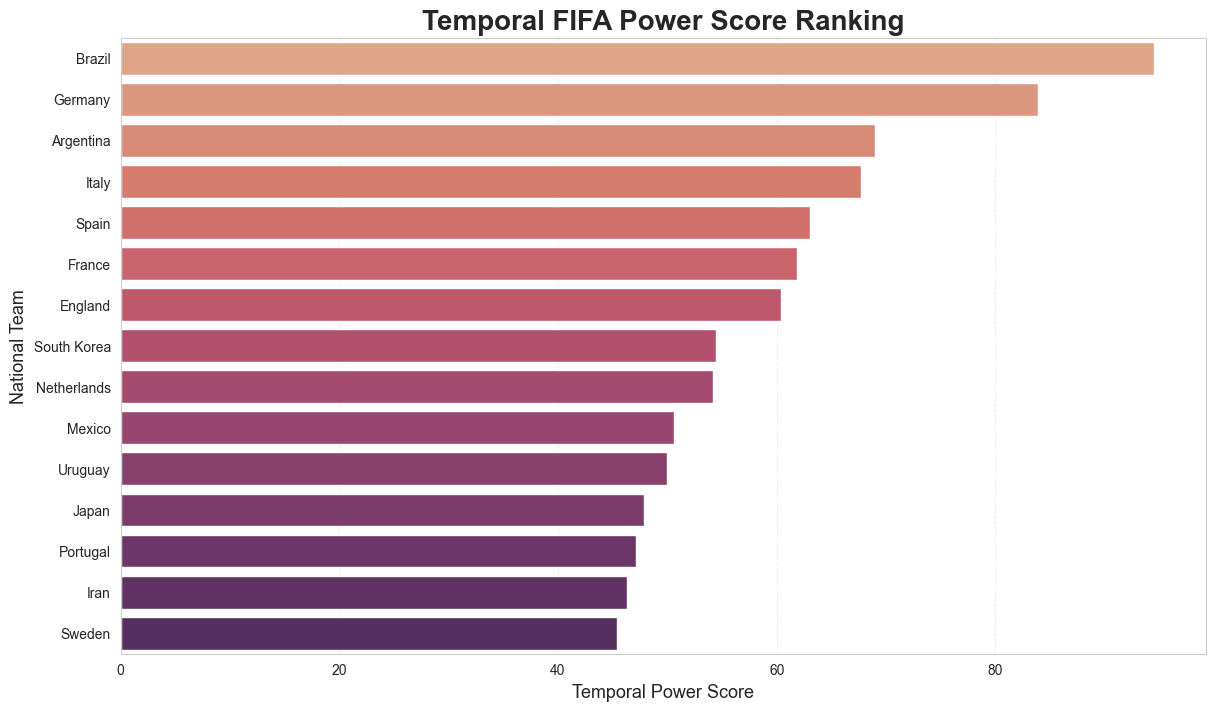

In [68]:
# 🎨 Temporal FIFA Ranking

plt.figure(figsize=(14,8))

sns.barplot(
    x=temporal_ranking.values,
    y=temporal_ranking.index,
    palette="flare"
)

plt.title(
    "Temporal FIFA Power Score Ranking",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel(
    "Temporal Power Score",
    fontsize=13
)

plt.ylabel(
    "National Team",
    fontsize=13
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.show()

plt.tight_layout()

💡 📌 Observation:

The temporal weighting strategy significantly modernized the FIFA Power Score ranking by prioritizing recent performances over historical matches from earlier decades.

Teams with strong contemporary performance, such as Spain, France, and Portugal, gained relevance, while historically dominant but less competitive modern teams experienced a relative decline.

This approach creates a ranking system that better reflects current football strength and competitive momentum, making it substantially more suitable for predictive modeling and tournament simulation tasks.

---